In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import scipy.io
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sb
import gc

# sc.settings.verbosity = 3
# sc.logging.print_versions()

### Analyze data

In [12]:
adata = sc.read('/local/home/am/EX_M/datasets/scRNA/heart/heart_preprocessed.h5ad')
adata

AnnData object with n_obs × n_vars = 60668 × 27350
    obs: 'nCount_RNA', 'nFeature_RNA', 'age_group', 'cell_source', 'cell_states', 'sample', 'age.order', 'age.days.GA', 'size.CRL', 'size.NRL', 'stage', 'integration.groups', 'integrated_snn_res.0.1', 'clusters.low.res', 'clusters.high.res', 'clusters.res.2', 'clusters.res.3', 'condition', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm

In [4]:
adata.obs

,nCount_RNA,nFeature_RNA,age_group,cell_source,cell_states,sample,age.order,age.days.GA,size.CRL,size.NRL,...,is_primary_data,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
GCGCGATCATACGCCG-alexsc,7071.0,2321,NA,F - Apex,foetal,alexsc,F5,67.0,NaN,NaN,...,True,tissue,fibroblast,10x 3' v2,normal,female,apex of heart,unknown,10th week post-fertilization stage,NKCYKgS=h^
GCATGTAAGTATTGGA-alexsc,4345.0,1601,NA,F - Apex,foetal,alexsc,F5,67.0,NaN,NaN,...,True,tissue,fibroblast,10x 3' v2,normal,female,apex of heart,unknown,10th week post-fertilization stage,Tc-7&J*Gbo
GACTGCGAGCTGAACG-alexsc,4533.0,1608,NA,F - Apex,foetal,alexsc,F5,67.0,NaN,NaN,...,True,tissue,fibroblast,10x 3' v2,normal,female,apex of heart,unknown,10th week post-fertilization stage,_}j*xZ=USa
CCTTTCTTCTATCGCC-alexsc,7752.0,2341,NA,F - Apex,foetal,alexsc,F5,67.0,NaN,NaN,...,True,tissue,fibroblast,10x 3' v2,normal,female,apex of heart,unknown,10th week post-fertilization stage,c72z};4{d<
CCAATCCAGCCACGCT-alexsc,10831.0,3109,NA,F - Apex,foetal,alexsc,F5,67.0,NaN,NaN,...,True,tissue,fibroblast,10x 3' v2,normal,female,apex of heart,unknown,10th week post-fertilization stage,&OS^Sj5*tY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AACTTTCAGGGCACTA-1-HCAHeart7850540,939.0,428,60-65,A - Cells,nan,HCAHeart7850540,A3,NaN,NaN,NaN,...,False,tissue,fetal cardiomyocyte,10x 3' v2,normal,male,heart right ventricle,unknown,seventh decade stage,hHB$xzuJS1
AGACGTTTCTGTTGAG-1-HCAHeart7850541,1730.0,703,60-65,A - Cells,nan,HCAHeart7850541,A3,NaN,NaN,NaN,...,False,tissue,cardiac muscle cell,10x 3' v2,normal,male,left cardiac atrium,unknown,seventh decade stage,eqLm=n{1;w
GGCTCGAGTGACTACT-1-HCAHeart7850539,2728.0,1264,60-65,A - Cells,nan,HCAHeart7850539,A3,NaN,NaN,NaN,...,False,tissue,innate lymphoid cell,10x 3' v2,normal,male,heart left ventricle,unknown,seventh decade stage,AW1m}eGgny
AGTGAGGCATCGGACC-1-HCAHeart7850542,3419.0,1242,60-65,A - Cells,nan,HCAHeart7850542,A3,NaN,NaN,NaN,...,False,tissue,cardiac muscle cell,10x 3' v2,normal,male,right cardiac atrium,unknown,seventh decade stage,?4J_97PIM+


In [13]:
adata.obs['cell_type'].value_counts()

cell_type
fibroblast                        8837
cardiac muscle cell               8272
myeloid cell                      8228
unknown                           5359
capillary endothelial cell        5064
smooth muscle cell                4406
innate lymphoid cell              3715
pericyte                          3510
neuron                            2850
endocardial cell                  2423
mesothelial cell of epicardium    1595
endothelial cell                  1567
endothelial cell of artery        1537
fetal cardiomyocyte               1391
vein endothelial cell              896
adipocyte                          701
cardiac mesenchymal cell           317
Name: count, dtype: int64

/local/home/am/miniconda3/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


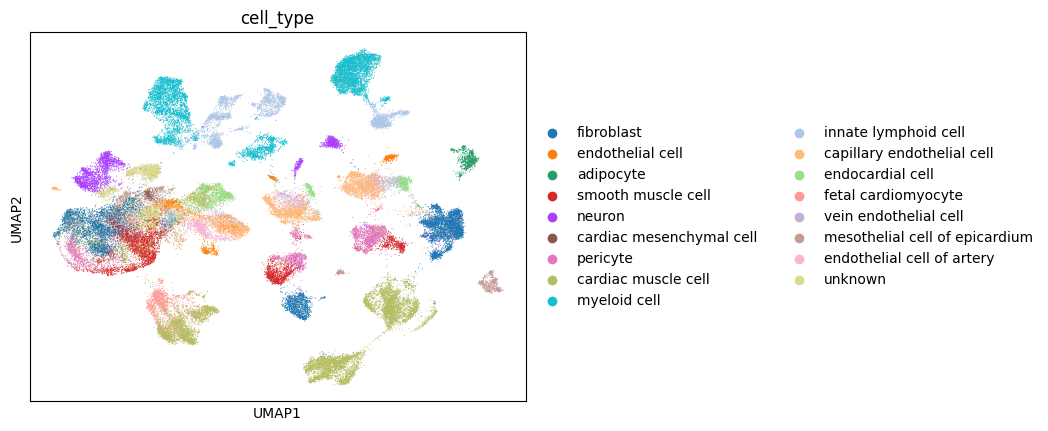

In [14]:
sc.pp.highly_variable_genes(adata, n_top_genes=4000)
sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], ncols=2)

In [19]:
train = sc.read('/local/home/am/EX_M/datasets/scRNA/heart/seed_32/scFoundation/train/heart_train_processed.h5ad')
train

/local/home/am/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 48534 × 19265
    obs: 'nCount_RNA', 'nFeature_RNA', 'age_group', 'cell_source', 'cell_states', 'sample', 'age.order', 'age.days.GA', 'size.CRL', 'size.NRL', 'stage', 'integration.groups', 'integrated_snn_res.0.1', 'clusters.low.res', 'clusters.high.res', 'clusters.res.2', 'clusters.res.3', 'condition', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [21]:
train.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 70322444 stored elements and shape (48534, 19265)>

In [34]:
# find ratio of non-zero entries in train.X
(train.X > 0).sum() / (train.X.shape[0] * train.X.shape[1])

0.07521056595577505

In [20]:
print(((train.X > 0).sum(axis=1) >= 7000).sum())

train = train[train.obs[(train.X > 0).sum(axis=1) < 7000].index]
train

0


View of AnnData object with n_obs × n_vars = 48534 × 19265
    obs: 'nCount_RNA', 'nFeature_RNA', 'age_group', 'cell_source', 'cell_states', 'sample', 'age.order', 'age.days.GA', 'size.CRL', 'size.NRL', 'stage', 'integration.groups', 'integrated_snn_res.0.1', 'clusters.low.res', 'clusters.high.res', 'clusters.res.2', 'clusters.res.3', 'condition', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [22]:
# save the train data
train.write('/local/home/am/EX_M/datasets/scRNA/heart/seed_32/scFoundation/train/heart_train_processed.h5ad')

In [23]:
test = sc.read('/local/home/am/EX_M/datasets/scRNA/heart/seed_32/scFoundation/test/heart_test_processed.h5ad')
test

/local/home/am/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 6067 × 19265
    obs: 'nCount_RNA', 'nFeature_RNA', 'age_group', 'cell_source', 'cell_states', 'sample', 'age.order', 'age.days.GA', 'size.CRL', 'size.NRL', 'stage', 'integration.groups', 'integrated_snn_res.0.1', 'clusters.low.res', 'clusters.high.res', 'clusters.res.2', 'clusters.res.3', 'condition', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [24]:
print(((test.X > 0).sum(axis=1) >= 7000).sum())

test = test[test.obs[(test.X > 0).sum(axis=1) < 7000].index]
test

0


View of AnnData object with n_obs × n_vars = 6067 × 19265
    obs: 'nCount_RNA', 'nFeature_RNA', 'age_group', 'cell_source', 'cell_states', 'sample', 'age.order', 'age.days.GA', 'size.CRL', 'size.NRL', 'stage', 'integration.groups', 'integrated_snn_res.0.1', 'clusters.low.res', 'clusters.high.res', 'clusters.res.2', 'clusters.res.3', 'condition', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [25]:
# save the test data

test.write('/local/home/am/EX_M/datasets/scRNA/heart/seed_32/scFoundation/test/heart_test_processed.h5ad')

In [26]:
val = sc.read('/local/home/am/EX_M/datasets/scRNA/heart/seed_32/scFoundation/validation/heart_val_processed.h5ad')
val

/local/home/am/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 6067 × 19265
    obs: 'nCount_RNA', 'nFeature_RNA', 'age_group', 'cell_source', 'cell_states', 'sample', 'age.order', 'age.days.GA', 'size.CRL', 'size.NRL', 'stage', 'integration.groups', 'integrated_snn_res.0.1', 'clusters.low.res', 'clusters.high.res', 'clusters.res.2', 'clusters.res.3', 'condition', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [27]:
print(((val.X > 0).sum(axis=1) >= 7000).sum())

val = val[val.obs[(val.X > 0).sum(axis=1) < 7000].index]

0


In [28]:
# save the val data

val.write('/local/home/am/EX_M/datasets/scRNA/heart/seed_32/scFoundation/validation/heart_val_processed.h5ad')

In [29]:
train.obs['celltype'].value_counts()

celltype
fibroblast                        7069
cardiac muscle cell               6618
myeloid cell                      6582
unknown                           4287
capillary endothelial cell        4051
smooth muscle cell                3525
innate lymphoid cell              2972
pericyte                          2808
neuron                            2280
endocardial cell                  1938
mesothelial cell of epicardium    1276
endothelial cell                  1254
endothelial cell of artery        1230
fetal cardiomyocyte               1113
vein endothelial cell              717
adipocyte                          561
cardiac mesenchymal cell           253
Name: count, dtype: int64

In [30]:
test.obs['celltype'].value_counts()

celltype
fibroblast                        883
cardiac muscle cell               827
myeloid cell                      823
unknown                           536
capillary endothelial cell        506
smooth muscle cell                440
innate lymphoid cell              372
pericyte                          351
neuron                            286
endocardial cell                  242
mesothelial cell of epicardium    160
endothelial cell                  157
endothelial cell of artery        154
fetal cardiomyocyte               139
vein endothelial cell              89
adipocyte                          70
cardiac mesenchymal cell           32
Name: count, dtype: int64

In [31]:
val.obs['celltype'].value_counts()

celltype
fibroblast                        885
cardiac muscle cell               827
myeloid cell                      823
unknown                           536
capillary endothelial cell        507
smooth muscle cell                441
innate lymphoid cell              371
pericyte                          351
neuron                            284
endocardial cell                  243
mesothelial cell of epicardium    159
endothelial cell                  156
endothelial cell of artery        153
fetal cardiomyocyte               139
vein endothelial cell              90
adipocyte                          70
cardiac mesenchymal cell           32
Name: count, dtype: int64